# Ejercicio PCA (Principal Component Analysis)
En este ejercicio vas a trabajar con un dataset de información de ciudadanos como el estado civil, número de hijos, qué gastos e ingresos tiene, etc...

Se cuenta con un target, que es si el ciudadano va a alquilar o a comprar una vivienda. Para ello,  con PCA

### Importamos librerias
Principales librerías que usarás durante el notebook.

In [15]:
# Tratamiento de datos
# ==============================================================================
import numpy as np
import pandas as pd


# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')

# Preprocesado y modelado
# ==============================================================================
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

### Cargamos datos de entrada
1. Carga el csv *comprar_alquilar.csv*
2. Obtén la información básica: columnas, dimensiones, descripción de las variables, missings...

In [16]:
alquilar = pd.read_csv('data/comprar_alquilar.csv')
alquilar.head()

,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
0,6000,1000,0,600,50000,400000,0,2,2,1
1,6745,944,123,429,43240,636897,1,3,6,0
2,6455,1033,98,795,57463,321779,2,1,8,1
3,7098,1278,15,254,54506,660933,0,0,3,0
4,6167,863,223,520,41512,348932,0,0,3,1


In [17]:
alquilar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ingresos        202 non-null    int64
 1   gastos_comunes  202 non-null    int64
 2   pago_coche      202 non-null    int64
 3   gastos_otros    202 non-null    int64
 4   ahorros         202 non-null    int64
 5   vivienda        202 non-null    int64
 6   estado_civil    202 non-null    int64
 7   hijos           202 non-null    int64
 8   trabajo         202 non-null    int64
 9   comprar         202 non-null    int64
dtypes: int64(10)
memory usage: 15.9 KB


### Visualicemos las dimensiones
Realiza un análisis univariante. Realiza la gráfica que consideres para cada variable, diferenciando por colores el target (*comprar*).

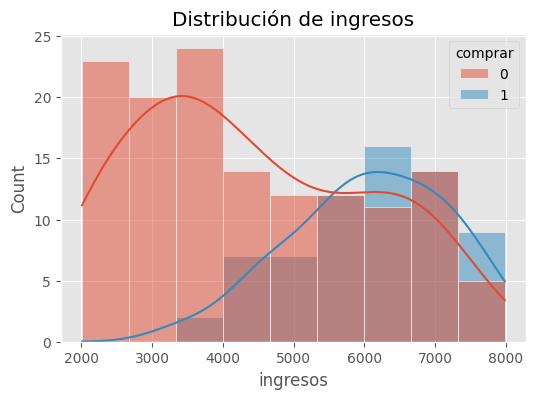

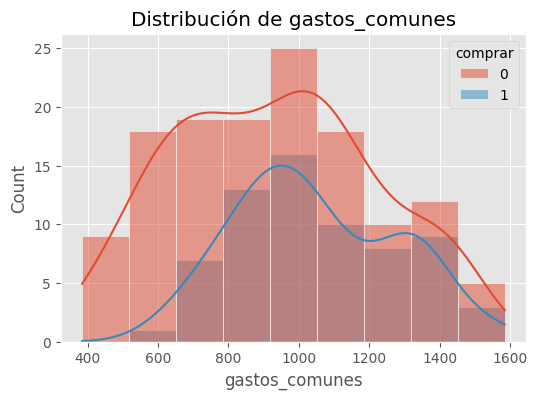

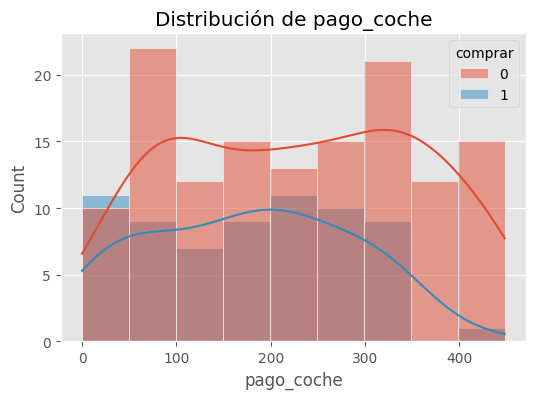

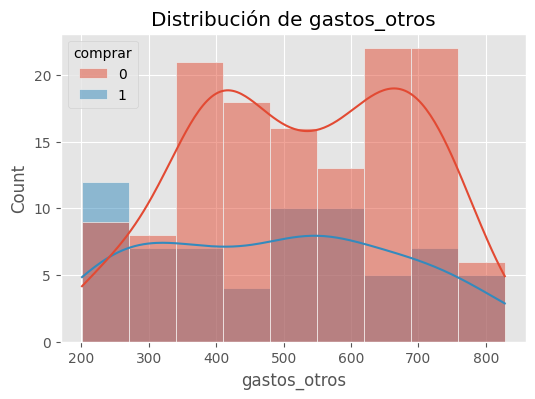

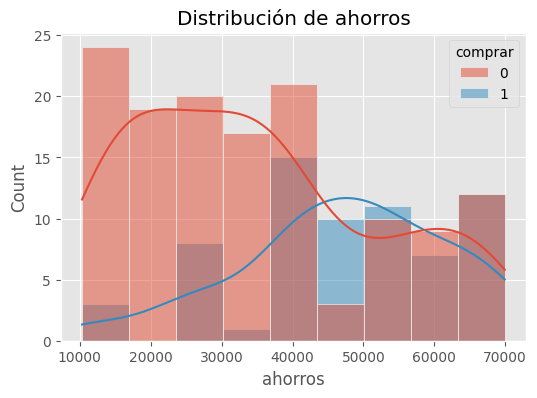

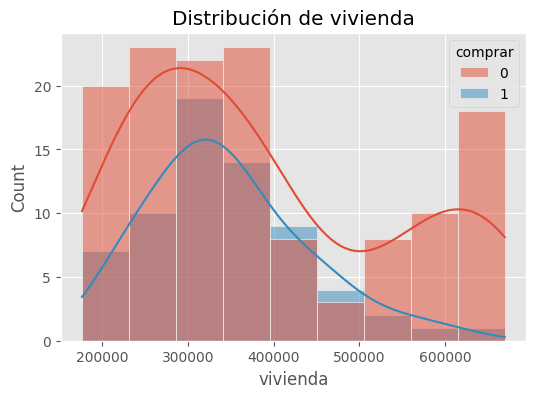

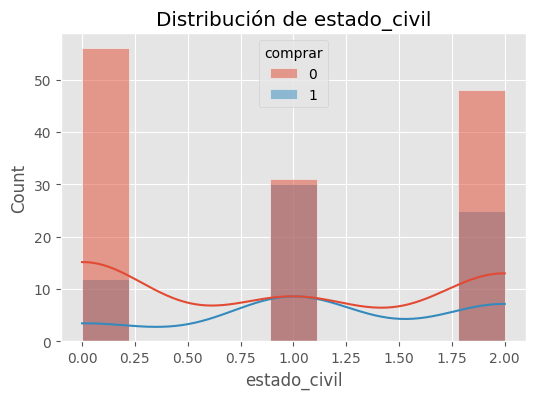

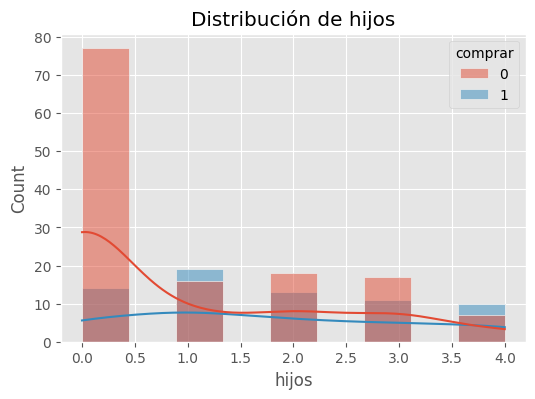

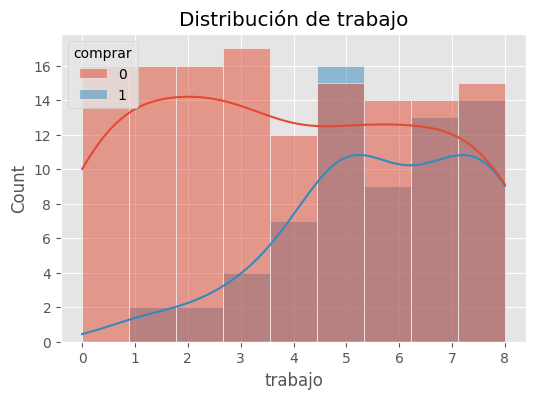

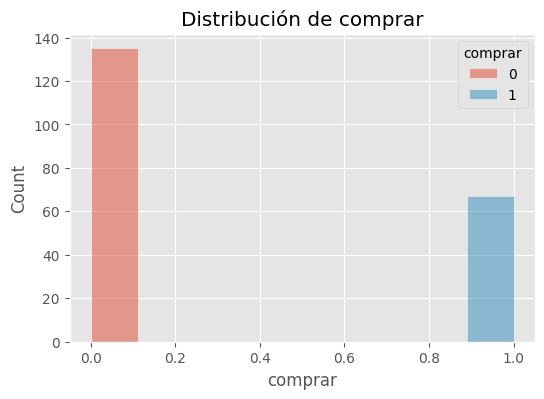

In [18]:
import seaborn as sns

# Separar variables numéricas
num_cols = alquilar.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data=alquilar, x=col, hue='comprar', kde=True)
    plt.title(f'Distribución de {col}')
    plt.show()

## Estandariza los datos
Como el objetivo de estos primeros apartados no es encontrar el mejor modelo con el mejor accuracy, por sencillez, no es necesario dividir en train y test.

In [19]:
from sklearn.preprocessing import StandardScaler

# Quitamos el target
X = alquilar.drop('comprar', axis=1)
y = alquilar['comprar']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Aplicamos PCA
Aplica el algoritmo de PCA para 9 components, es decir, para todas las features

In [20]:
pca = PCA(n_components=9)
X_pca = pca.fit_transform(X_scaled)

### Veamos cómo de buenos predictores son las nuevas dimensiones
Responde a las siguientes preguntas:
1. ¿Cuánta varianza explica cada Principal Component?
2. ¿Y de manera acumulada empezando por el PC1?
3. ¿Cuánta varianza explicarían sólo 5 componentes?

In [21]:
# Varianza por componente
print("Varianza explicada por cada componente:")
print(pca.explained_variance_ratio_)

# Varianza acumulada
var_acum = np.cumsum(pca.explained_variance_ratio_)
print("\nVarianza acumulada:")
print(var_acum)

# Varianza con 5 componentes
print("\nVarianza con 5 componentes:")
print(var_acum[4])

Varianza explicada por cada componente:
[0.29913557 0.23294923 0.11711241 0.10685622 0.09635279 0.05629866
 0.04145579 0.03017819 0.01966115]

Varianza acumulada:
[0.29913557 0.5320848  0.64919721 0.75605343 0.85240621 0.90870487
 0.95016066 0.98033885 1.        ]

Varianza con 5 componentes:
0.8524062117714313


### Graficamos la variacion explicada acumulada
Representa en un diagrama de lineas la evolución de la varianza acumulada en función de los PC

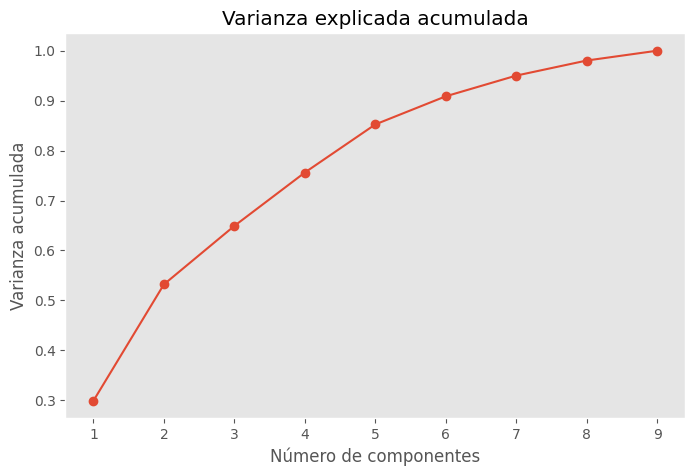

In [22]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(var_acum)+1), var_acum, marker='o')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.title('Varianza explicada acumulada')
plt.grid()
plt.show()

### Veamos la correlación entre las nuevas componentes y las dimensiones originales
Representa en un mapa de calor los PCA vs las variables originales. Esta información la puedes obtener del atributo de PCA *components_*.

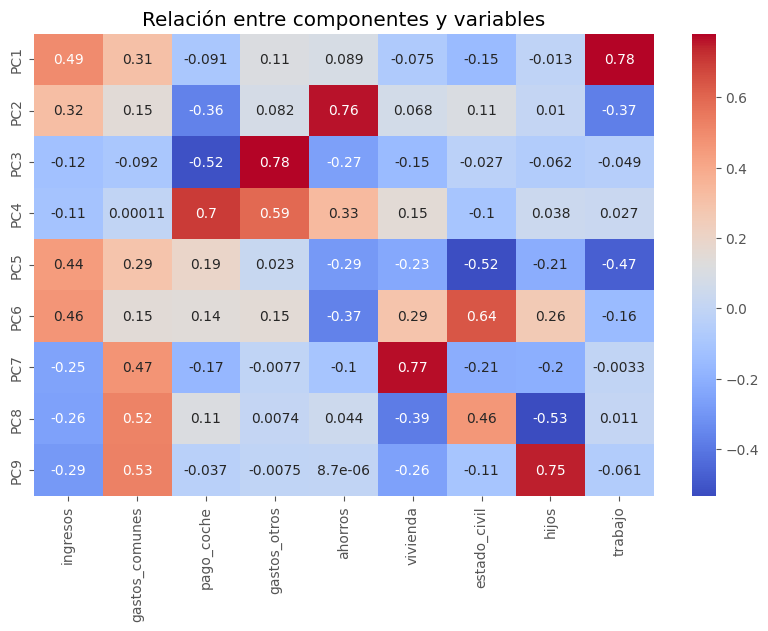

In [23]:
plt.figure(figsize=(10,6))
sns.heatmap(pca.components_.T, 
            cmap='coolwarm',
            annot=True, 
            xticklabels=X.columns,
            yticklabels=[f'PC{i+1}' for i in range(pca.n_components_)])
plt.title('Relación entre componentes y variables')
plt.show()

## Predicciones
1. Divide en train y test
2. Prepara un pipeline compuesto por:
    - StandardScaler,
    - PCA de 5 componentes
    - Un clasificador
3. Entrena
4. Predice con test
5. Calcula el accuracy score en train y test
6. Representa la matriz de confusión
7. ¿Qué combinación de parámetros y componentes mejoraría el accuracy en test?
8. Vuelve a iterar de nuevo con un gridsearch
9. Guarda tu mejor modelo

Accuracy train: 0.8012422360248447
Accuracy test: 0.7317073170731707


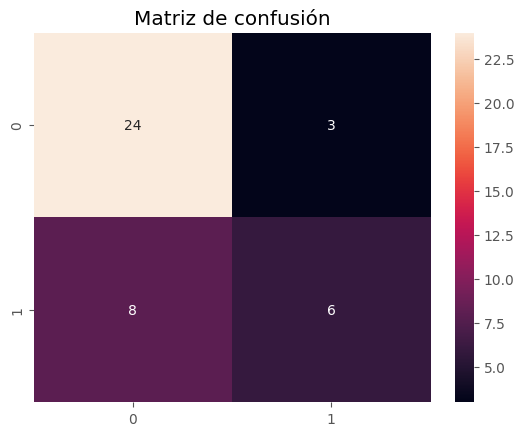

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5)),
    ('model', LogisticRegression())
])

# Entrenar
pipe.fit(X_train, y_train)

# Predicciones
y_pred_train = pipe.predict(X_train)
y_pred_test = pipe.predict(X_test)

# Accuracy
print("Accuracy train:", accuracy_score(y_train, y_pred_train))
print("Accuracy test:", accuracy_score(y_test, y_pred_test))

# Matriz de confusión
sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, fmt='d')
plt.title("Matriz de confusión")
plt.show()

#### Con GridSearhc

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'pca__n_components': [3, 5, 7, 9],
    'model__C': [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)

# Evaluación final
y_pred = grid.predict(X_test)
print("Accuracy test mejorado:", accuracy_score(y_test, y_pred))

Mejores parámetros: {'model__C': 1, 'pca__n_components': 9}
Accuracy test mejorado: 0.8780487804878049


### Guardar Modelo

In [ ]:
import joblib

joblib.dump(grid.best_estimator_, 'mejor_modelo_pca.pkl')

['mejor_modelo_pca.pkl']